In [1]:
# Model semiparametryczny – weryfikacja założenia proporcjonalnych hazardów, ewentualnie włączenie zmiennych zależnych od czasu, interpretacja modelu

In [2]:
import pandas as pd

In [8]:
df = pd.read_csv('aids_data.csv', sep=';')

In [9]:
print(df.head())

   time  trt  age     wtkg  hemo  homo  drugs  karnof  oprior  z30  ...  str2  \
0   948    2   48  89.8128     0     0      0     100       0    0  ...     0   
1  1002    3   61  49.4424     0     0      0      90       0    1  ...     1   
2   961    3   45  88.4520     0     1      1      90       0    1  ...     1   
3  1166    3   47  85.2768     0     1      0     100       0    1  ...     1   
4  1090    0   43  66.6792     0     1      0     100       0    1  ...     1   

   strat  symptom  treat  offtrt  cd40  cd420  cd80  cd820  cid  
0      1        0      1       0   422    477   566    324    0  
1      3        0      1       0   162    218   392    564    1  
2      3        0      1       1   326    274  2063   1893    0  
3      3        0      1       0   287    394  1590    966    0  
4      3        0      0       0   504    353   870    782    0  

[5 rows x 24 columns]


In [10]:
df

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,1091,3,21,53.2980,1,0,0,100,0,1,...,1,3,0,1,1,152,109,561,720,0
2135,395,0,17,102.9672,1,0,0,100,0,1,...,1,3,0,0,1,373,218,1759,1030,0
2136,1104,2,53,69.8544,1,1,0,90,0,1,...,1,3,0,1,0,419,364,1391,1041,0
2137,465,0,14,60.0000,1,0,0,100,0,0,...,0,1,0,0,0,166,169,999,1838,1


In [11]:
# Sprawdzenie braków danych w wybranych kolumnach
selected_cols = ['time', 'trt', 'age', 'hemo', 'homo', 'drugs', 'karnof', 'cd40', 'cid']
missing_counts = df[selected_cols].isnull().sum()
print(missing_counts)

time      0
trt       0
age       0
hemo      0
homo      0
drugs     0
karnof    0
cd40      0
cid       0
dtype: int64


In [12]:
import pandas as pd
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import numpy as np

In [13]:
from lifelines import CoxPHFitter

# Usuwanie brakujących danych w używanych kolumnach
df = df.dropna(subset=["trt", "hemo", "cd40", "age", "karnof", "gender", "homo", "drugs"])
# Zmienne do modelu
variables = ['trt', 'cd40', 'age', 'karnof', 'drugs']

cph = CoxPHFitter()
cph.fit(df[variables + ['time', 'cid']], duration_col='time', event_col='cid')
# Wyświetlenie wyników
cph.print_summary(model="untransformed variables", decimals=3)

<lifelines.CoxPHFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
      baseline estimation = breslow
   number of observations = 2139
number of events observed = 521
   partial log-likelihood = -3793.222
         time fit was run = 2026-03-31 10:20:17 UTC
                    model = untransformed variables

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
trt       -0.183     0.832     0.040          -0.262          -0.105               0.770               0.900
cd40      -0.004     0.996     0.000          -0.005          -0.003               0.995               0.997
age        0.009     1.010     0.005          -0.000           0.019               1.000               1.019
karnof    -0.031     0.969     0.007          -0.045          -0.018               0.956               0.983
drugs     -0.367     0.692     0.146          -0.653          -0.082               0.520               0.922

           cmp to      z       p  -log2(p)
covariate                                 
trt         0.000 -4.596 <0.0005    17.825
cd40        0.000 -9.130 <0.0005    63.665
age         0.000  1.906   0.057     4.143
karnof      0.000 -4.508 <0.0005    17.220
drugs       0.000 -2.519   0.012     6.409
---
Concordance = 0.655
Partial AIC = 7596.443
log-likelihood ratio test = 144.966 on 5 df
-log2(p) of ll-ratio test = 95.682


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'trt' failed the non-proportional test: p-value is 0.0200.

   Advice: with so few unique values (only 4), you can include `strata=['trt', ...]` in the call in
`.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'cd40' failed the non-proportional test: p-value is 0.0003.

   Advice 1: the functional form of the variable 'cd40' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'cd40' using pd.cut, and then specify it in `strata=['cd40',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a mo

[[<Axes: xlabel='rank-transformed time\n(p=0.0211)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0200)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0003)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0003)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4383)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4666)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6918)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7230)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4728)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4707)'>]]

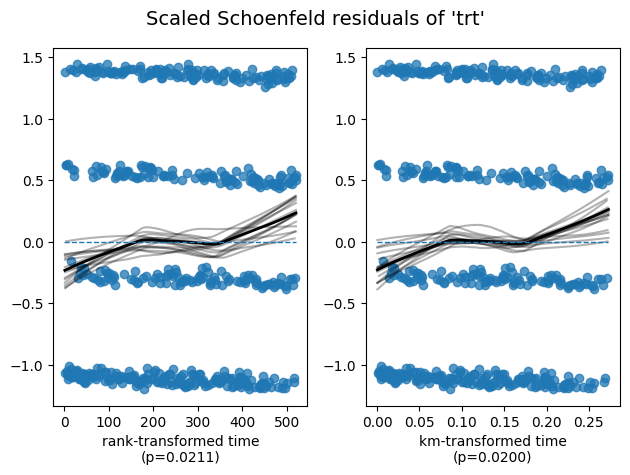

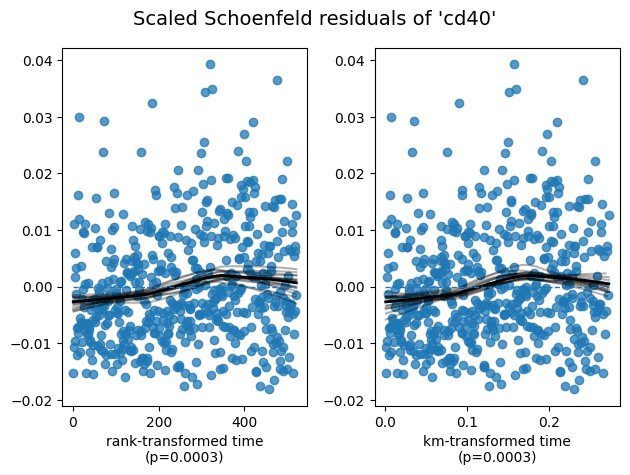

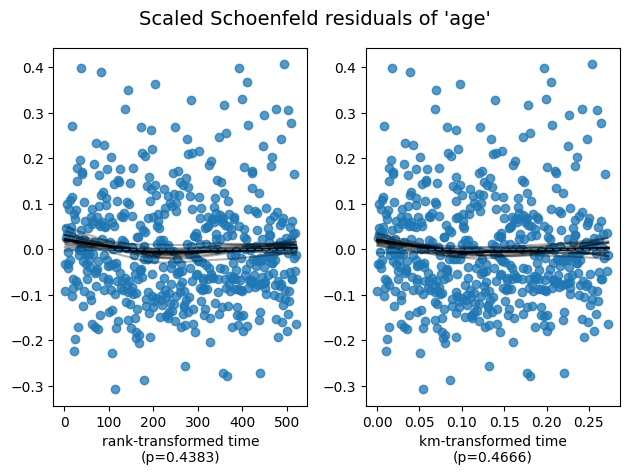

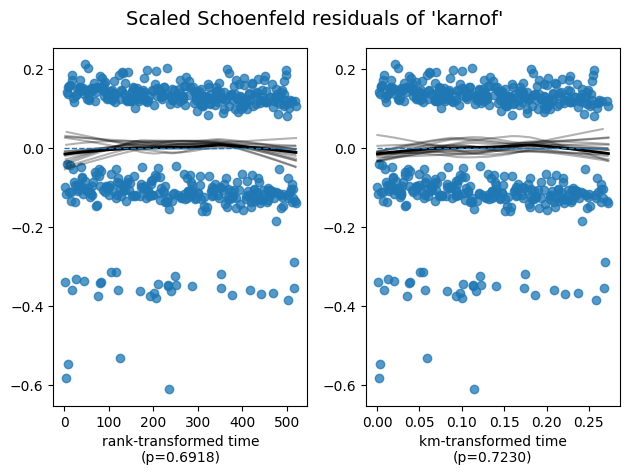

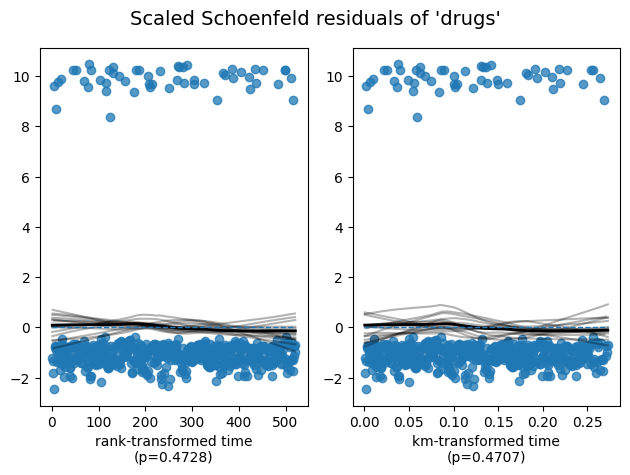

In [14]:
# Sprawdzenie założeń 
cph.check_assumptions(df[variables + ['time', 'cid']], p_value_threshold=0.05, show_plots= True)

In [15]:
print(df['trt'].unique())

[2 3 0 1]


In [16]:
cph.fit(df[variables + ['time', 'cid']], duration_col='time', event_col='cid', strata=['trt'])
# Wyświetlenie wyników
cph.print_summary(model="trt in strata", decimals=3)

<lifelines.CoxPHFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
                   strata = trt
      baseline estimation = breslow
   number of observations = 2139
number of events observed = 521
   partial log-likelihood = -3075.040
         time fit was run = 2026-03-31 10:21:05 UTC
                    model = trt in strata

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
cd40      -0.004     0.996     0.000          -0.005          -0.003               0.995               0.997
age        0.010     1.010     0.005           0.000           0.020               1.000               1.020
karnof    -0.029     0.971     0.007          -0.043          -0.016               0.958               0.984
drugs     -0.333     0.717     0.146          -0.620          -0.047               0.538               0.954

           cmp to      z       p  -log2(p)
covariate                                 
cd40        0.000 -9.256 <0.0005    65.355
age         0.000  1.969   0.049     4.352
karnof      0.000 -4.245 <0.0005    15.483
drugs       0.000 -2.279   0.023     5.463
---
Concordance = 0.643
Partial AIC = 6158.080
log-likelihood ratio test = 126.551 on 4 df
-log2(p) of ll-ratio test = 85.281

In [17]:
cph.check_assumptions(df[variables + ['time', 'cid']], p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'cd40' failed the non-proportional test: p-value is 0.0002.

   Advice 1: the functional form of the variable 'cd40' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'cd40' using pd.cut, and then specify it in `strata=['cd40',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-v

[]

In [18]:
print(df['cd40'].describe())

count    2139.000000
mean      350.501169
std       118.573863
min         0.000000
25%       263.500000
50%       340.000000
75%       423.000000
max      1199.000000
Name: cd40, dtype: float64


In [19]:
df_strata_cd40 = df[variables + ['time', 'cid']].copy()
df_strata_cd40['cd40_strata'] = pd.qcut(df_strata_cd40['cd40'], q=5)

df_strata_cd40[['cd40', 'cd40_strata']].head()

,cd40,cd40_strata
0,422,"(373.0, 444.4]"
1,162,"(-0.001, 247.0]"
2,326,"(309.0, 373.0]"
3,287,"(247.0, 309.0]"
4,504,"(444.4, 1199.0]"


<lifelines.CoxPHFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
                   strata = ['cd40_strata', 'trt']
      baseline estimation = breslow
   number of observations = 2139
number of events observed = 521
   partial log-likelihood = -2276.346
         time fit was run = 2026-03-31 10:21:20 UTC
                    model = stratified cd40 and trt

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.011     1.011     0.005           0.001           0.020               1.001               1.021
karnof    -0.028     0.973     0.007          -0.041          -0.014               0.959               0.986
drugs     -0.345     0.709     0.147          -0.632          -0.057               0.532               0.944

           cmp to      z       p  -log2(p)
covariate                                 
age         0.000  2.112   0.035     4.849
karnof      0.000 -3.946 <0.0005    13.617
drugs       0.000 -2.350   0.019     5.736
---
Concordance = 0.557
Partial AIC = 4558.693
log-likelihood ratio test = 24.614 on 3 df
-log2(p) of ll-ratio test = 15.715

<Axes: xlabel='log(HR) (95% CI)'>

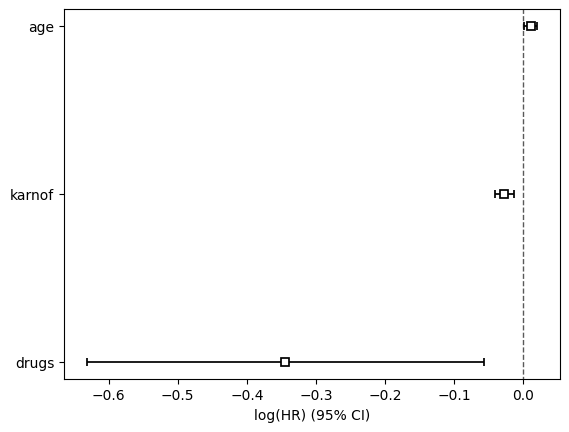

In [30]:
cph.print_summary(3, model="stratified cd40 and trt")
cph.plot()

In [35]:
cph.check_assumptions(df_strata_cd40, p_value_threshold=0.05)

C:\Users\aptak\AppData\Roaming\Python\Python313\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


Proportional hazard assumption looks okay.


[]

In [36]:
from lifelines.utils import to_episodic_format

df_long = to_episodic_format(df[variables + ['time', 'cid']], duration_col='time', event_col='cid', time_gaps=100.)
df_long.head(25)

,stop,start,cid,age,cd40,drugs,id,karnof,trt
0,100.0,0.0,0,48,422,0,0,100,2
1,200.0,100.0,0,48,422,0,0,100,2
2,300.0,200.0,0,48,422,0,0,100,2
3,400.0,300.0,0,48,422,0,0,100,2
4,500.0,400.0,0,48,422,0,0,100,2
5,600.0,500.0,0,48,422,0,0,100,2
6,700.0,600.0,0,48,422,0,0,100,2
7,800.0,700.0,0,48,422,0,0,100,2
8,900.0,800.0,0,48,422,0,0,100,2
9,948.0,900.0,0,48,422,0,0,100,2


In [37]:
df_long['time*cd40'] = df_long['cd40'] * df_long['stop']

In [38]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()

ctv.fit(df_long,
        id_col='id',
        event_col='cid',
        start_col='start',
        stop_col='stop',
        strata=['trt'])

<lifelines.CoxTimeVaryingFitter: fitted with 19823 periods, 2139 subjects, 521 events>

In [39]:
ctv.print_summary(5, model="cd40 * time interaction")

<lifelines.CoxTimeVaryingFitter: fitted with 19823 periods, 2139 subjects, 521 events>
         event col = 'cid'
            strata = trt
number of subjects = 2139
 number of periods = 19823
  number of events = 521
partial log-likelihood = -3037.01573
  time fit was run = 2026-03-31 10:28:46 UTC
             model = cd40 * time interaction

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
age        0.00905   1.00909   0.00499        -0.00074         0.01883             0.99926             1.01901
cd40       0.00459   1.00460   0.00101         0.00261         0.00658             1.00261             1.00660
drugs     -0.35335   0.70233   0.14629        -0.64007        -0.06663             0.52725             0.93554
karnof    -0.03040   0.97006   0.00693        -0.04399        -0.01681             0.95696             0.98333
time*cd40 -0.00001   0.99999   0.00000        -0.00002        -0.00001             0.99998             0.99999

           cmp to        z       p  -log2(p)
covariate                                   
age       0.00000  1.81242 0.06992   3.83811
cd40      0.00000  4.53800 0.00001  17.42594
drugs     0.00000 -2.41546 0.01572   5.99166
karnof    0.00000 -4.38457 0.00001  16.39283
time*cd40 0.00000 -8.86295  <5e-06  60.15457
---
Partial AIC = 6084.03146
log-likelihood ratio test = 202.59930 on 5 df
-log2(p) of ll-ratio test = 136.54018